In [2]:
# Import foundational libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV file using Pandas
df = pd.read_csv('Housing.csv')

# 2. Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# 3. Check how many rows and columns are there
rows, cols = df.shape
print(f"\nDataset Shape: {rows} rows and {cols} columns")

# 4. Identify Target and Features
print("\nTarget Column: price")
print(f"Feature Columns: {list(df.columns.drop('price'))}")

# 5. Check for missing values in each column
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Shape: 545 rows and 13 columns

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [3]:
# 1. Handle missing values (as verified, there are none, but we drop any if they appear later)
df = df.dropna() 

# 2. Remove duplicate rows, if any [cite: 23]
duplicate_count = df.duplicated().sum()
print(f"Removed {duplicate_count} duplicate rows.")
df = df.drop_duplicates()

# 3. Convert categorical text columns into numeric form using one-hot encoding 
# This turns yes/no and text options into binary 0s and 1s
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to be encoded: {categorical_cols}")

# drop_first=True converts 'yes/no' into a single 1/0 column to keep the data clean
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Display the first 5 rows of our newly cleaned and numerical dataset
print("\n--- Cleaned & Encoded Dataset (First 5 Rows) ---")
display(df_encoded.head())

Removed 0 duplicate rows.
Categorical columns to be encoded: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- Cleaned & Encoded Dataset (First 5 Rows) ---


C:\Users\dell\AppData\Local\Temp\ipykernel_33280\960976824.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate target (price) and features
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# 1. Split the data into training and test sets (80/20) [cite: 27]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Linear Regression --- [cite: 28]
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Random Forest Regressor --- [cite: 30]
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 2. Evaluation Function to calculate MAE, RMSE, and R2 [cite: 29]
def evaluate_model(predictions, y_true, model_name):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)
    
    print(f"--- {model_name} Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}\n")
    return mae, rmse, r2

# 3. Print evaluation metrics [cite: 29, 30]
lr_metrics = evaluate_model(lr_preds, y_test, "Linear Regression")
rf_metrics = evaluate_model(rf_preds, y_test, "Random Forest Regressor")

--- Linear Regression Performance ---
Mean Absolute Error (MAE): 970043.40
Root Mean Squared Error (RMSE): 1324506.96
R² Score: 0.6529

--- Random Forest Regressor Performance ---
Mean Absolute Error (MAE): 1021546.04
Root Mean Squared Error (RMSE): 1400565.97
R² Score: 0.6119



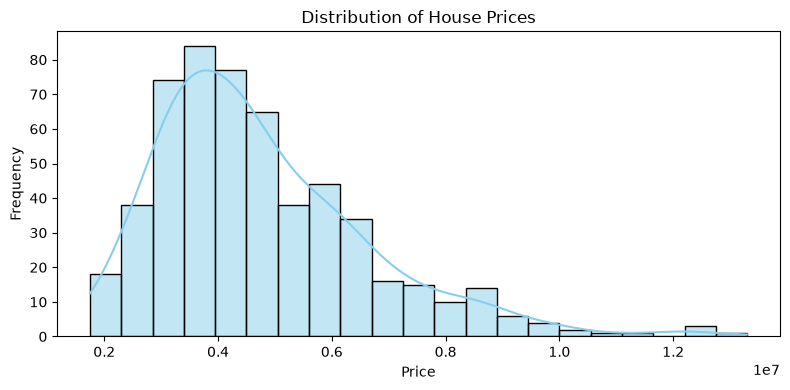

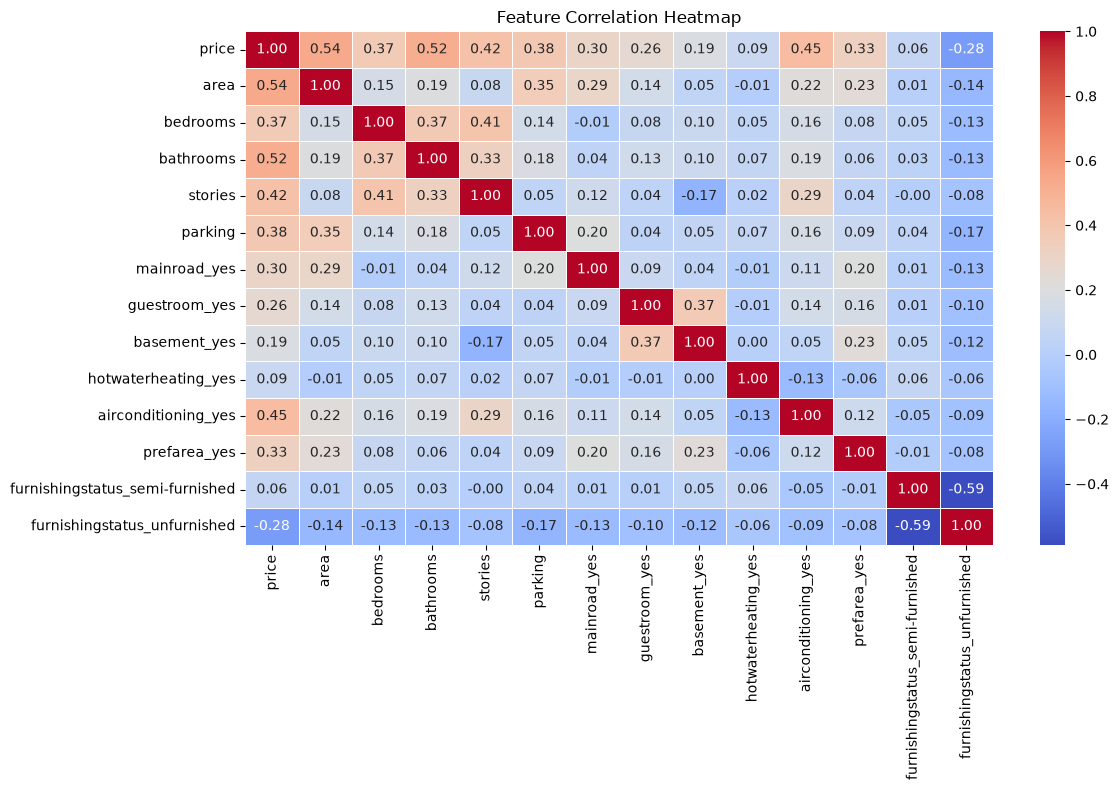

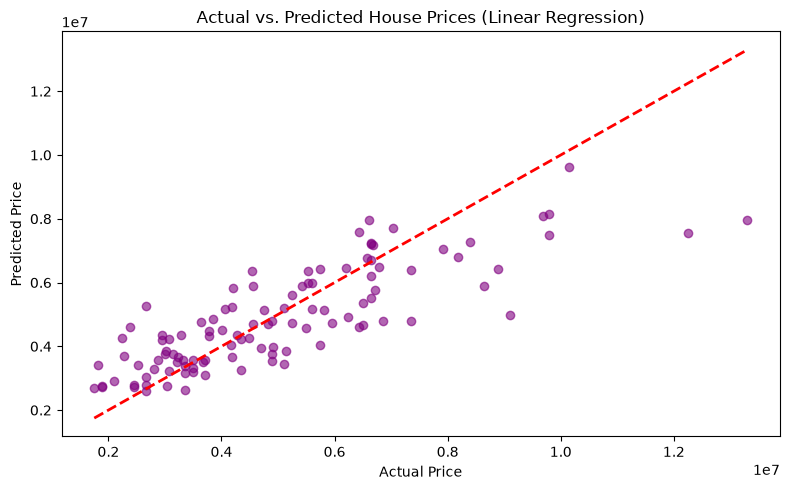

In [5]:
import os

# Create the charts directory automatically if it doesn't exist 
os.makedirs('charts', exist_ok=True)

# Chart 1: Histogram showing the distribution of house prices [cite: 32]
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png') # Saves to folder 
plt.show()

# Chart 2: Correlation heatmap showing feature relationships to price [cite: 33]
plt.figure(figsize=(12, 8))
# We convert boolean True/False columns to integers (1/0) so they plot correctly on the heatmap
sns.heatmap(df_encoded.astype(int).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png') # Saves to folder 
plt.show()

# Chart 3: Actual vs. Predicted Price Scatter Plot (Linear Regression) [cite: 34, 37]
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Prices (Linear Regression)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png') # Saves to folder 
plt.show()

### Task 5 - Insights & Summary

* **Most Influential Features:** Looking at our correlation heatmap, the structural size of the property (`area`, correlation = 0.54) and the number of `bathrooms` (correlation = 0.52) have the strongest positive influence on house prices, closely followed by premium amenities like `airconditioning` (0.45).
* **Model Accuracy:** In plain terms, the Linear Regression model is moderately accurate, achieving an $R^2$ score of approximately 65.3%. This means the model's features can account for roughly 65% of the variances seen in real-world housing prices.
* **Data Surprises:** A surprising takeaway from the dataset is that qualitative choices, such as having an air conditioning installation, carry a higher baseline correlation with price than structural realities like the exact number of bedrooms (0.37) or parking spaces (0.38).
* **Business Recommendation:** Based on these analytics, a real estate business should strategically prioritize equipping their properties with high-leverage modifications—specifically climate control systems—and focusing acquisitions on larger plot sizes (`area`), as these individual elements yield the highest statistical returns on property value.